# Linear Regression From Scratch

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter

### Lin Reg Cost Function

$$ J(w,b)
=
\frac{1}{2m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)} - y^{(i)}\right)^2 $$

### Gradient Equations

a. with respect to each w (based on num of features): 
$$ \frac{\partial J}{\partial w_j}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)} - y^{(i)}\right)x_j^{(i)} $$

b. with respect to b: $$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right) $$

### Gradient Descent Implementation

In [44]:
def linreg_gradient_descent(theta, X, Y, num_iter=1000, lr=0.01):
    '''
    Params:
        theta - params ([b, w_1, w_2, ...])
        X - sample data
        Y - sample target values
        num_iter - num of gradient descent iterations
        lr - learning rate hyperparameter
    
    Returns:
        theta - updated params
        RSS - residual sum of squares; magnitude of error (lower is better)
        cost_history - stores cost value of each iteration
    '''

    m = len(Y)
    cost_history = []

    for i in range(num_iter):
        # computing predictions
        y_hat = X @ theta
        y_diff = y_hat - Y

        # computing cost
        cost = (1 / (2 * m)) * np.sum(y_diff ** 2)
        cost_history.append(cost)
        
        # computing param gradients 
        grad = (1 / m) * (X.T @ y_diff)

        # updating params
        theta = theta - (lr * grad)

    # compute RSS
    y_diff = (X @ theta) - Y
    RSS = np.sum(np.square(y_diff))

    return theta, RSS, cost_history


### GD Function Testing

Final theta:
[[504105.54794625]
 [233645.84986976]
 [-13367.26031507]]

RSS (Evaluation of training):
1202904964711376.2

First 5 costs:
[np.float64(294392931215.36346), np.float64(291171719592.2933), np.float64(288018990227.4983), np.float64(284933245495.993), np.float64(281913021507.88586)]

Last 5 costs:
[np.float64(138583525042.33698), np.float64(138583524272.18784), np.float64(138583523510.99475), np.float64(138583522758.65314), np.float64(138583522015.05972)]


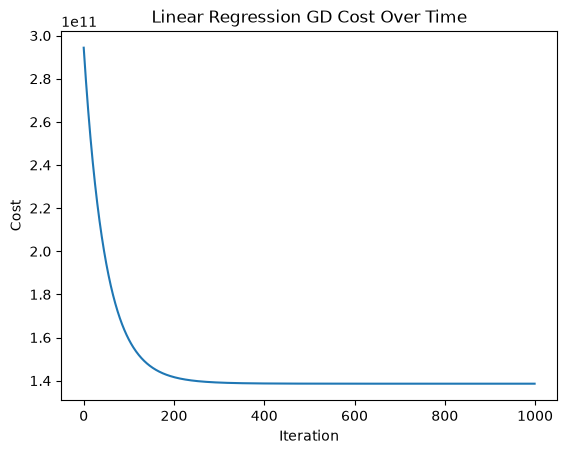

In [45]:
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "nehalbirla/vehicle-dataset-from-cardekho",
  "CAR DETAILS FROM CAR DEKHO.csv",
)

X_raw = df[["year", "km_driven"]].values
Y = df[["selling_price"]].values

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_scaled = (X_raw - X_mean) / X_std

m = len(Y)
X = np.c_[np.ones((m, 1)), X_scaled]

theta = np.zeros((X.shape[1], 1))

theta, RSS, cost_history = linreg_gradient_descent(theta, X, Y, num_iter=1000, lr=0.01)

Y_pred = X @ theta

print("Final theta:")
print(theta)

print("\nRSS (Evaluation of training):")
print(RSS)

print("\nFirst 5 costs:")
print(cost_history[:5])

print("\nLast 5 costs:")
print(cost_history[-5:])

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Linear Regression GD Cost Over Time")
plt.show()